# Simple Linear Regression from Scratch
## Goal
We have study-hours-vs-score data for 5 students. We want to fit a straight line `y = m*x + c` that predicts a student's **score** from their **study hours**, then check how good that fit is.

This notebook builds the same linear regression three ways, in increasing order of abstraction:
1. **Method 1** — plain NumPy, step-by-step, no class
2. **Method 2** — plain NumPy, wrapped in a reusable `LinearRegression` class
3. **Method 3** — scikit-learn's built-in `LinearRegression`, used as a correctness check on Methods 1 & 2


## Method 1 — Without using scikit-learn or a class


In [ ]:
# numpy: array math for the regression formulas
# matplotlib: visualizing the data and the fitted line
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#====================
# Step 1. Our data
#====================
# x = study hours, y = exam score, one pair per student
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 6, 9])
print(f"x={x}  y={y}")


x=[1 2 3 4 5]  y=[2 4 5 6 9]


Using the values above, find a straight line `y = mx + c`, where `m` is the **slope** and `c` (called `b` below) is the **intercept**.

In [ ]:
#==================================
# Step 2. Find the mean of x and y
#==================================
# The least-squares formulas for slope and intercept are both centered
# on the mean of x and the mean of y, so we compute those first.
x_mean = np.mean(x)
y_mean = np.mean(y)
print(f"X mean: {x_mean} \ny mean:{y_mean}")

X mean: 3.0 
y mean:5.2


##Slope formula -least squares problem##
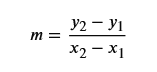




In [ ]:
#=================================
# Step 3. Calculate the slope (m)
#=================================
# Least-squares slope: m = sum((x - x_mean)(y - y_mean)) / sum((x - x_mean)^2)
# i.e. covariance of x and y, divided by the variance of x.
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)
m = numerator / denominator
print(f"numerator: {numerator} denominator: {denominator}")
print("Slope=", m)

numerator: 16.0 denominator: 10.0
Slope= 1.6


Intercept formula

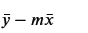

In [ ]:
#===================================
# Step 4. Calculation of intercept
#===================================
# Once we know the slope, the best-fit line must pass through (x_mean, y_mean),
# so: b = y_mean - m * x_mean
b = y_mean - m * x_mean
print(f"Intercept: {b:.2f}")

Intercept: 0.40


In [ ]:
#=========================
# Step 5. Make predictions
#=========================
# Plug every x back into y = m*x + b to get the model's fitted values.
y_predict = m * x + b
print("Y original", y)
print("y predicted", y_predict)

Y original [2 4 5 6 9]
y predicted [2.  3.6 5.2 6.8 8.4]


1. TSS (Total Sum of Squares)

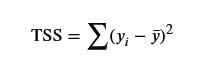

2. RSS (Residual Sum of Squares)

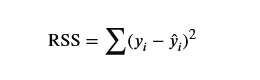

3.  (R-squared) -A standardized metric that scales between 0 and 1 (or 0% to 100%).


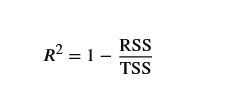

In [ ]:
#===================================
# Step 6. How good is our model? - R2
#===================================
# R-squared = 1 - RSS/TSS, where:
#   TSS (Total Sum of Squares)    = how much y varies around its own mean
#   RSS (Residual Sum of Squares) = how much y varies around our predictions
#

tss = np.sum((y - y_mean) ** 2)
rss = np.sum((y - y_predict) ** 2)
r2 = 1 - (rss / tss)
print("R squared=", r2)

R squared= 0.9552238805970149


**Sanity check:** this matches `sklearn.metrics.r2_score(y, y_predict)` (see Method 3 below), confirming the fix is correct. The original buggy code always reported `R squared= 1.0`, which would have hidden any real fit quality issues.

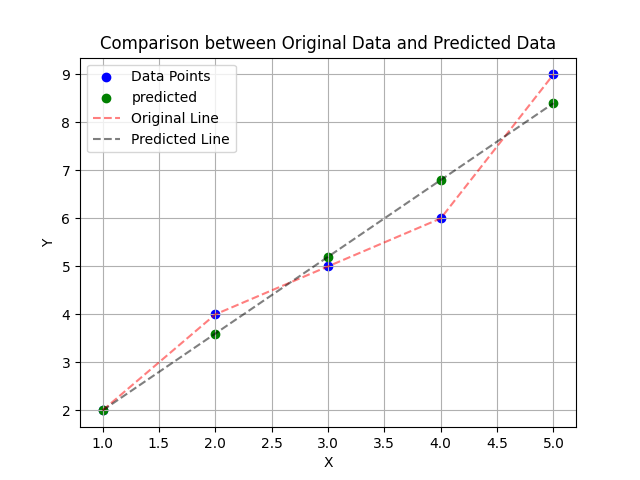

In [ ]:
# Plotting the scatter points
plt.scatter(x, y, color='blue', label='Data Points')

plt.scatter(x, y_predict, color="green", label="predicted")
# Optional: Add a line connecting the points
plt.plot(x, y, color='red', linestyle='--', alpha=0.5, label='Original Line')
plt.plot(x, y_predict, color="black", linestyle='--', alpha=0.5, label='Predicted Line')

# Customizing labels and title
plt.title('Comparison between Original Data and Predicted Data')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

## Method 2 — Without using scikit-learn, but with a class

Same math as Method 1, refactored into a reusable `LinearRegression` class so `fit()`/`predict()` can be called on any dataset without repeating the formulas.

In [ ]:
import numpy as np

class LinearRegression:
    """Ordinary least-squares simple linear regression (one feature), built from scratch."""

    def __init__(self):
        self.m = None  # slope, learned in fit()
        self.b = None  # intercept, learned in fit()

    def fit(self, x, y):
        """Estimate slope (m) and intercept (b) from training data x, y
        using the same closed-form least-squares formulas as Method 1."""
        x_mean = np.mean(x)
        y_mean = np.mean(y)

        numerator = np.sum((x - x_mean) * (y - y_mean))
        denominator = np.sum((x - x_mean) ** 2)

        self.m = numerator / denominator
        self.b = y_mean - self.m * x_mean
        # No explicit return needed for fit, it modifies self

    def predict(self, x):
        """Apply the learned line y = m*x + b to new x values."""
        return self.m * x + self.b

#x=np.array([1,2,3,4,5])
#y=np.array([2,4,5,6,9])

L1 = LinearRegression()
L1.fit(x, y)  # Call fit to calculate m and b

print("Model slope (m):", L1.m)
print("Model intercept (b):", L1.b)

print("Predicted values:", L1.predict(x))  # Pass x to the predict method

Model slope (m): 1.5999999999999999
Model intercept (b): 0.40000000000000036
Predicted values: [2.  3.6 5.2 6.8 8.4]


### Predict for new X values

Now let's use our trained `LinearRegression` model to predict `y` values for a new set of `x` values (i.e. study hours we haven't seen before).

In [ ]:
x_new = np.array([6, 7, 10])
y_new_predict = L1.predict(x_new)

print(f"New X values: {x_new}")
print(f"Predicted Y values for new X: {y_new_predict}")

New X values: [ 6  7 10]
Predicted Y values for new X: [10.  11.6 16.4]


## Method 3 — Using scikit-learn

Finally, use scikit-learn's battle-tested `LinearRegression` and metric functions as an independent check on Methods 1 & 2. If the from-scratch slope, intercept, and R² match sklearn's, we can trust the manual implementation.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# sklearn expects a 2D array of shape (n_samples, n_features) for X
X = x.reshape(-1, 1)
# Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

# View results
print(f"Slope (m): {model.coef_[0]:.2f}")
print(f"Intercept (b): {model.intercept_:.2f}")
print(f"Predicted values: {model.predict(X)}")

# Generate predictions
y_pred = model.predict(X)

# Calculate regression performance metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

# Output results

print(f"Model Slope (m)           : {model.coef_[0]:.2f}")
print(f"Model Intercept (b)       : {model.intercept_:.2f}")
print("-" * 35)
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Mean Squared Error (MSE)  : {mse:.2f}")
print(f"Root Mean Squared Error   : {rmse:.2f}")
print(f"R-squared Score (R\u00b2)      : {r2:.4f}")

Slope (m): 1.60
Intercept (b): 0.40
Predicted values: [2.  3.6 5.2 6.8 8.4]
Model Slope (m)           : 1.60
Model Intercept (b)       : 0.40
-----------------------------------
Mean Absolute Error (MAE) : 0.40
Mean Squared Error (MSE)  : 0.24
Root Mean Squared Error   : 0.49
R-squared Score (R²)      : 0.9552


**Sanity check:** `R-squared Score (R²)` here is `0.9552`, matching the corrected manual R² calculation in Method 1 above (`0.9552238805970149`). This confirms the from-scratch slope, intercept, and R² formulas are all correct once the bug is fixed.

In [ ]:
x_new = np.array([6, 7, 10])
ypred = model.predict(x_new.reshape(-1, 1))
print(ypred)

[10.  11.6 16.4]


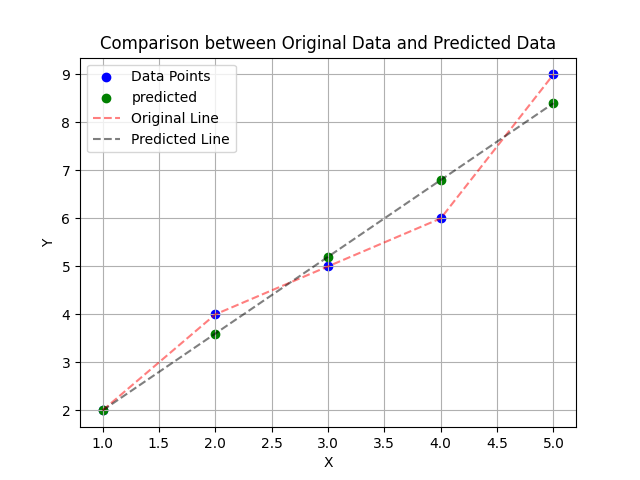

In [ ]:
# Plotting the scatter points

plt.scatter(x, y, color='blue', label='Data Points')

plt.scatter(x, y_pred, color="green", label="predicted")
# Optional: Add a line connecting the points
plt.plot(x, y, color='red', linestyle='--', alpha=0.5, label='Original Line')
plt.plot(x, y_pred, color="black", linestyle='--', alpha=0.5, label='Predicted Line')

# Customizing labels and title
plt.title('Comparison between Original Data and Predicted Data (sklearn model)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.grid(True)

# Display the plot
plt.show()